In [ ]:
# STEP 0 — Install packages

import subprocess
subprocess.run(["pip", "install", "ftfy", "scikit-learn", "matplotlib", "seaborn", "pandas", "numpy", "-q"])

import pandas as pd
import numpy as np
import re
import ast
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
print("libraries loaded")


libraries loaded


In [ ]:
# STEP 1 — LOAD DATA

# loading the cleaned dataset from preprocessing
df = pd.read_csv("snacks_cleaned.csv")

# already have the cleaned version so raw text isn't needed
if "ingredients_text" in df.columns:
    df = df.drop(columns=["ingredients_text"])

df = df.dropna(subset=["ingredients_cleaned"])

print(f"rows: {len(df):,}")
print(f"columns: {df.columns.tolist()}")

rows: 99,958
columns: ['product_name', 'categories_en', 'ingredients_cleaned', 'ingredients_list']


In [ ]:
# STEP 2 — HARMFUL INGREDIENTS DATABASE
# lookup table for harmful ingredients
# each entry has the category, a severity weight, and linked diseases
# weights are based on how strongly each ingredient is associated with harm
# e.g. trans fats get 25 because FDA banned them and WHO flagged them
# artificial colors get 10-15 based on the Southampton study findings
# lower weights for emulsifiers since the evidence is more recent and less conclusive

HARMFUL_DB = {
    # ─── artificial colors ────────────────────────────────────────────────────
    # Southampton study (2007) linked these to hyperactivity in children
    "e102":             ("artificial_color", 15, ["hyperactivity", "allergies", "asthma", "cancer risk"]),
    "tartrazine":       ("artificial_color", 15, ["hyperactivity", "allergies", "asthma"]),
    "yellow 5":         ("artificial_color", 15, ["hyperactivity", "allergies", "asthma"]),   # US name for e102/tartrazine
    "fdc yellow 5":     ("artificial_color", 15, ["hyperactivity", "allergies", "asthma"]),   # FD&C label variant
    "fd&c yellow 5":    ("artificial_color", 15, ["hyperactivity", "allergies", "asthma"]),

    "e104":             ("artificial_color", 12, ["hyperactivity", "allergies"]),
    "quinoline yellow": ("artificial_color", 12, ["hyperactivity", "allergies"]),              # common name for e104

    "e110":             ("artificial_color", 15, ["hyperactivity", "allergies", "asthma", "cancer risk"]),
    "yellow 6":         ("artificial_color", 15, ["hyperactivity", "allergies", "asthma"]),   # US name for e110
    "fdc yellow 6":     ("artificial_color", 15, ["hyperactivity", "allergies", "asthma"]),
    "fd&c yellow 6":    ("artificial_color", 15, ["hyperactivity", "allergies", "asthma"]),
    "sunset yellow":    ("artificial_color", 15, ["hyperactivity", "allergies", "asthma"]),   # alternate name for e110

    "e122":             ("artificial_color", 12, ["hyperactivity", "allergies", "cancer risk"]),
    "carmoisine":       ("artificial_color", 12, ["hyperactivity", "allergies", "cancer risk"]),  # name for e122
    "azorubine":        ("artificial_color", 12, ["hyperactivity", "allergies", "cancer risk"]),

    "e123":             ("artificial_color", 20, ["cancer risk", "birth defects"]),
    "amaranth":         ("artificial_color", 20, ["cancer risk", "birth defects"]),            # name for e123 (banned in US)

    "e124":             ("artificial_color", 15, ["hyperactivity", "allergies", "cancer risk"]),
    "ponceau 4r":       ("artificial_color", 15, ["hyperactivity", "allergies", "cancer risk"]),  # name for e124

    "e127":             ("artificial_color", 12, ["thyroid issues", "hyperactivity"]),
    "erythrosine":      ("artificial_color", 12, ["thyroid issues", "hyperactivity"]),         # name for e127
    "red 3":            ("artificial_color", 12, ["thyroid issues", "hyperactivity"]),         # US name (FDA proposed ban 2023)
    "fdc red 3":        ("artificial_color", 12, ["thyroid issues", "hyperactivity"]),

    "e129":             ("artificial_color", 15, ["hyperactivity", "allergies", "cancer risk"]),
    "allura red":       ("artificial_color", 15, ["hyperactivity", "allergies", "cancer risk"]),
    "red 40":           ("artificial_color", 15, ["hyperactivity", "allergies", "cancer risk"]),   # most common US name for e129
    "red40":            ("artificial_color", 15, ["hyperactivity", "allergies", "cancer risk"]),   # no-space variant
    "red no 40":        ("artificial_color", 15, ["hyperactivity", "allergies", "cancer risk"]),
    "fdc red 40":       ("artificial_color", 15, ["hyperactivity", "allergies", "cancer risk"]),
    "fd&c red 40":      ("artificial_color", 15, ["hyperactivity", "allergies", "cancer risk"]),
    "red 40 lake":      ("artificial_color", 15, ["hyperactivity", "allergies", "cancer risk"]),   # lake = coated version

    "e131":             ("artificial_color", 18, ["cancer risk"]),
    "patent blue":      ("artificial_color", 18, ["cancer risk"]),                             # name for e131

    "e132":             ("artificial_color", 10, ["allergies", "nausea"]),
    "indigotine":       ("artificial_color", 10, ["allergies", "nausea"]),
    "blue 2":           ("artificial_color", 10, ["allergies", "nausea"]),                     # US name for e132
    "fdc blue 2":       ("artificial_color", 10, ["allergies", "nausea"]),
    "fd&c blue 2":      ("artificial_color", 10, ["allergies", "nausea"]),

    "e133":             ("artificial_color", 10, ["allergies", "hyperactivity"]),
    "brilliant blue":   ("artificial_color", 10, ["allergies", "hyperactivity"]),
    "blue 1":           ("artificial_color", 10, ["allergies", "hyperactivity"]),              # US name for e133
    "fdc blue 1":       ("artificial_color", 10, ["allergies", "hyperactivity"]),
    "fd&c blue 1":      ("artificial_color", 10, ["allergies", "hyperactivity"]),
    "blue 1 lake":      ("artificial_color", 10, ["allergies", "hyperactivity"]),

    "e142":             ("artificial_color", 12, ["cancer risk", "allergies"]),
    "green s":          ("artificial_color", 12, ["cancer risk", "allergies"]),
    "green 3":          ("artificial_color", 12, ["cancer risk", "allergies"]),                # FD&C Green No. 3
    "fdc green 3":      ("artificial_color", 12, ["cancer risk", "allergies"]),

    "e150":             ("artificial_color",  8, ["hyperactivity", "digestive issues"]),
    "caramel color":    ("artificial_color",  8, ["hyperactivity", "digestive issues"]),       # class III/IV contain 4-MEI (IARC 2B carcinogen)
    "caramel colour":   ("artificial_color",  8, ["hyperactivity", "digestive issues"]),       # UK/EU spelling

    "e151":             ("artificial_color", 12, ["allergies", "cancer risk"]),
    "black bn":         ("artificial_color", 12, ["allergies", "cancer risk"]),

    "e155":             ("artificial_color", 12, ["allergies", "cancer risk"]),
    "brown ht":         ("artificial_color", 12, ["allergies", "cancer risk"]),

    # ─── preservatives ────────────────────────────────────────────────────────
    # sodium nitrite gets 20 since WHO classifies it as Group 1 carcinogen (processed meat)
    "e200":             ("preservative",  8, ["allergies", "digestive issues"]),
    "sorbic acid":      ("preservative",  8, ["allergies", "digestive issues"]),               # name for e200

    "e202":             ("preservative",  8, ["allergies", "digestive issues"]),
    "potassium sorbate": ("preservative", 8, ["allergies", "digestive issues"]),               # name for e202 — found in 3,762 products

    "e203":             ("preservative",  6, ["allergies"]),
    "calcium sorbate":  ("preservative",  6, ["allergies"]),

    "e210":             ("preservative", 15, ["cancer risk", "allergies", "hyperactivity"]),
    "benzoic acid":     ("preservative", 15, ["cancer risk", "allergies", "hyperactivity"]),   # name for e210

    "e211":             ("preservative", 18, ["cancer risk", "ADHD", "allergies"]),
    "sodium benzoate":  ("preservative", 18, ["cancer risk", "ADHD", "allergies"]),

    "e212":             ("preservative", 15, ["cancer risk", "allergies"]),
    "potassium benzoate": ("preservative", 15, ["cancer risk", "allergies"]),

    "e213":             ("preservative", 15, ["cancer risk", "allergies"]),
    "calcium benzoate": ("preservative", 15, ["cancer risk", "allergies"]),

    "e220":             ("preservative", 12, ["asthma", "allergies", "headaches"]),
    "sulfur dioxide":   ("preservative", 12, ["asthma", "allergies", "headaches"]),           # US spelling of e220
    "sulphur dioxide":  ("preservative", 12, ["asthma", "allergies", "headaches"]),           # UK/EU spelling

    "e221":             ("preservative", 10, ["asthma", "allergies"]),
    "sodium sulfite":   ("preservative", 10, ["asthma", "allergies"]),
    "sodium sulphite":  ("preservative", 10, ["asthma", "allergies"]),

    "e222":             ("preservative", 10, ["asthma", "allergies"]),
    "e223":             ("preservative", 10, ["asthma", "allergies"]),
    "sodium metabisulfite":  ("preservative", 10, ["asthma", "allergies"]),                   # common name for e223
    "sodium metabisulphite": ("preservative", 10, ["asthma", "allergies"]),                   # UK spelling
    "sodium bisulfite":      ("preservative", 10, ["asthma", "allergies"]),

    "e224":             ("preservative", 10, ["asthma", "allergies"]),
    "potassium metabisulfite": ("preservative", 10, ["asthma", "allergies"]),

    # generic sulfite mentions — sulfite-sensitive asthmatics react to all forms
    "sulfites":         ("preservative", 10, ["asthma", "allergies", "headaches"]),
    "sulphites":        ("preservative", 10, ["asthma", "allergies", "headaches"]),
    "sulphite":         ("preservative", 10, ["asthma", "allergies"]),
    "sulfite":          ("preservative", 10, ["asthma", "allergies"]),
    "contains sulfites": ("preservative", 10, ["asthma", "allergies"]),

    "e250":             ("preservative", 20, ["cancer risk", "heart disease"]),
    "sodium nitrite":   ("preservative", 20, ["cancer risk", "heart disease"]),

    "e251":             ("preservative", 18, ["cancer risk", "heart disease"]),
    "sodium nitrate":   ("preservative", 18, ["cancer risk", "heart disease"]),                # WHO Group 2A carcinogen

    "e252":             ("preservative", 18, ["cancer risk"]),
    "potassium nitrate": ("preservative", 18, ["cancer risk"]),

    # generic nitrate mention — covers cured meat products where exact form isn't listed
    "nitrate":          ("preservative", 15, ["cancer risk", "heart disease"]),               # very common — 10,719 products

    "e280":             ("preservative",  8, ["digestive issues"]),
    "propionic acid":   ("preservative",  8, ["digestive issues"]),

    "e281":             ("preservative",  8, ["digestive issues"]),
    "sodium propionate": ("preservative",  8, ["digestive issues"]),                          # found in 1,252 products

    "e282":             ("preservative",  8, ["digestive issues"]),
    "calcium propionate": ("preservative", 8, ["digestive issues"]),                          # found in 695 products

    "e283":             ("preservative",  8, ["digestive issues"]),
    "potassium propionate": ("preservative", 8, ["digestive issues"]),

    "e262":             ("preservative",  6, ["digestive issues"]),
    "sodium diacetate": ("preservative",  6, ["digestive issues"]),                           # found in 311 products — mild acidity regulator

    "e320":             ("preservative", 15, ["cancer risk", "hormone disruption"]),
    "bha":              ("preservative", 15, ["cancer risk", "hormone disruption"]),

    "e321":             ("preservative", 15, ["cancer risk", "cholesterol increase"]),
    "bht":              ("preservative", 15, ["cancer risk", "cholesterol increase"]),

    "tbhq":             ("preservative", 18, ["cancer risk", "nausea", "vision disturbances"]),

    # ─── sweeteners ───────────────────────────────────────────────────────────
    # IARC classified aspartame as possibly carcinogenic (Group 2B) in 2023
    "e951":             ("sweetener", 15, ["headaches", "neurological issues", "cancer risk"]),
    "aspartame":        ("sweetener", 15, ["headaches", "neurological issues", "cancer risk"]),

    "e952":             ("sweetener", 12, ["cancer risk"]),
    "cyclamate":        ("sweetener", 12, ["cancer risk"]),
    "sodium cyclamate": ("sweetener", 12, ["cancer risk"]),                                   # full chemical name variant

    "e954":             ("sweetener", 12, ["cancer risk", "bladder issues"]),
    "saccharin":        ("sweetener", 12, ["cancer risk", "bladder issues"]),
    "sodium saccharin": ("sweetener", 12, ["cancer risk", "bladder issues"]),

    "e955":             ("sweetener",  8, ["digestive issues", "gut microbiome disruption"]),
    "sucralose":        ("sweetener",  8, ["digestive issues", "gut microbiome disruption"]),

    "e950":             ("sweetener", 10, ["headaches", "neurological issues"]),
    "acesulfame":       ("sweetener", 10, ["headaches", "neurological issues"]),
    "acesulfame k":     ("sweetener", 10, ["headaches", "neurological issues"]),              # K = potassium salt form
    "acesulfame-k":     ("sweetener", 10, ["headaches", "neurological issues"]),
    "ace k":            ("sweetener", 10, ["headaches", "neurological issues"]),

    "e968":             ("sweetener",  6, ["digestive issues"]),
    "erythritol":       ("sweetener",  6, ["digestive issues"]),                              # 2023 study linked high blood levels to clotting risk

    "e953":             ("sweetener",  6, ["digestive issues"]),
    "isomalt":          ("sweetener",  6, ["digestive issues"]),

    "e965":             ("sweetener",  6, ["digestive issues"]),
    "maltitol":         ("sweetener",  6, ["digestive issues"]),

    "e966":             ("sweetener",  6, ["digestive issues"]),
    "lactitol":         ("sweetener",  6, ["digestive issues"]),

    "e967":             ("sweetener",  6, ["digestive issues"]),
    "xylitol":          ("sweetener",  5, ["digestive issues"]),                              # toxic to pets; mild laxative effect in humans at high doses

    # ─── flavor enhancers ─────────────────────────────────────────────────────
    "e621":                 ("flavor_enhancer", 12, ["headaches", "obesity", "heart disease"]),
    "msg":                  ("flavor_enhancer", 12, ["headaches", "obesity", "allergies"]),
    "monosodium glutamate": ("flavor_enhancer", 12, ["headaches", "obesity"]),

    "e624":                 ("flavor_enhancer", 10, ["headaches", "digestive issues"]),
    "e625":                 ("flavor_enhancer", 10, ["headaches", "digestive issues"]),
    "e627":                 ("flavor_enhancer",  8, ["gout", "allergies"]),
    "disodium guanylate":   ("flavor_enhancer",  8, ["gout", "allergies"]),                  # name for e627
    "e631":                 ("flavor_enhancer",  8, ["gout", "allergies"]),
    "disodium inosinate":   ("flavor_enhancer",  8, ["gout", "allergies"]),                  # name for e631
    "e635":                 ("flavor_enhancer", 10, ["gout", "allergies", "skin reactions"]),
    "disodium ribonucleotides": ("flavor_enhancer", 10, ["gout", "allergies"]),              # name for e635

    # ─── additives ────────────────────────────────────────────────────────────
    # titanium dioxide — banned as food additive in EU 2022, still under review in US
    "e171":              ("additive", 15, ["cancer risk", "DNA damage"]),
    "titanium dioxide":  ("additive", 15, ["cancer risk", "DNA damage"]),

    "e172":              ("additive",  6, ["iron overload in excess"]),
    "iron oxides":       ("additive",  6, ["iron overload in excess"]),

    "e407":              ("additive", 12, ["digestive issues", "inflammation"]),
    "carrageenan":       ("additive", 12, ["digestive issues", "inflammation", "cancer risk"]),

    "e466":              ("additive",  6, ["digestive issues"]),
    "cellulose gum":     ("additive",  6, ["digestive issues"]),                              # common name for e466
    "sodium carboxymethylcellulose": ("additive", 6, ["digestive issues"]),

    "e551":              ("additive",  8, ["lung issues"]),
    "silicon dioxide":   ("additive",  8, ["lung issues"]),
    "silica":            ("additive",  8, ["lung issues"]),                                   # short name used on labels

    "potassium bromate": ("additive", 20, ["cancer risk", "kidney damage"]),                 # banned in EU/Canada, still legal some US states
    "bvo":               ("additive", 18, ["neurological issues", "thyroid issues"]),         # FDA moved to revoke authorization 2023

    # propylene glycol — FDA GRAS but linked to kidney issues at high doses
    "propylene glycol":  ("additive", 10, ["kidney issues", "nervous system effects"]),      # found in 1,792 products

    # EDTA — chelation agent, can deplete minerals; FDA limits to 75-365ppm depending on food
    "edta":              ("additive",  8, ["mineral depletion", "digestive issues"]),
    "calcium disodium edta": ("additive", 8, ["mineral depletion", "digestive issues"]),     # name on most ingredient labels
    "disodium edta":     ("additive",  8, ["mineral depletion", "digestive issues"]),

    # e471 — mono and diglycerides of fatty acids — can contain trace trans fats
    "e471":              ("additive",  8, ["digestive issues", "potential trans fat traces"]),  # 2,853 products
    "mono and diglycerides": ("additive", 8, ["digestive issues"]),
    "monoglycerides":    ("additive",  6, ["digestive issues"]),
    "diglycerides":      ("additive",  6, ["digestive issues"]),

    "e472":              ("additive",  8, ["digestive issues"]),                              # esters of mono and diglycerides
    "acetylated":        ("additive",  8, ["digestive issues"]),                              # acetylated mono/diglycerides
    "acetylated monoglycerides": ("additive", 8, ["digestive issues"]),

    "e475":              ("additive",  8, ["digestive issues"]),
    "polyglycerol esters": ("additive", 8, ["digestive issues"]),

    "e476":              ("additive",  8, ["digestive issues"]),                              # 1,384 products
    "pgpr":              ("additive",  8, ["digestive issues"]),                              # abbreviation for e476
    "polyglycerol polyricinoleate": ("additive", 8, ["digestive issues"]),

    # sodium stearoyl lactylate — Chassaing et al. (2015) style gut disruption evidence
    "e481":              ("emulsifier",  8, ["gut microbiome disruption", "digestive issues"]),  # 298 products
    "sodium stearoyl lactylate": ("emulsifier", 8, ["gut microbiome disruption", "digestive issues"]),
    "sodium stearoyl-2-lactylate": ("emulsifier", 8, ["gut microbiome disruption", "digestive issues"]),
    "ssl":               ("emulsifier",  8, ["gut microbiome disruption"]),                  # abbreviation used on some labels

    "e492":              ("emulsifier",  8, ["digestive issues"]),                            # 202 products
    "sorbitan tristearate": ("emulsifier", 8, ["digestive issues"]),

    # ─── trans fats ───────────────────────────────────────────────────────────
    # FDA officially banned partially hydrogenated oils in 2018 — highest weight
    "partially hydrogenated": ("trans_fat", 25, ["heart disease", "diabetes", "obesity", "stroke"]),
    "hydrogenated vegetable": ("trans_fat", 20, ["heart disease", "diabetes", "obesity"]),
    "hydrogenated palm":      ("trans_fat", 20, ["heart disease", "diabetes"]),
    "hydrogenated oil":       ("trans_fat", 20, ["heart disease", "diabetes"]),
    "hydrogenated fat":       ("trans_fat", 20, ["heart disease", "diabetes"]),               # generic variant seen on some labels
    "hydrogenated coconut":   ("trans_fat", 18, ["heart disease", "high cholesterol"]),
    "hydrogenated soybean":   ("trans_fat", 20, ["heart disease", "diabetes"]),
    "hydrogenated cottonseed": ("trans_fat", 20, ["heart disease", "diabetes"]),

    # ─── emulsifiers ──────────────────────────────────────────────────────────
    # Chassaing et al. (2015) in Nature linked polysorbates to gut microbiome disruption
    "e432":           ("emulsifier", 10, ["gut microbiome disruption"]),
    "polysorbate 20": ("emulsifier", 10, ["gut microbiome disruption"]),                     # name for e432
    "tween 20":       ("emulsifier", 10, ["gut microbiome disruption"]),

    "e433":           ("emulsifier", 10, ["gut microbiome disruption", "inflammation"]),
    "polysorbate 80": ("emulsifier", 10, ["gut microbiome disruption", "inflammation"]),
    "tween 80":       ("emulsifier", 10, ["gut microbiome disruption", "inflammation"]),

    "e434":           ("emulsifier", 10, ["gut microbiome disruption"]),
    "polysorbate 40": ("emulsifier", 10, ["gut microbiome disruption"]),                     # name for e434

    "e435":           ("emulsifier", 10, ["gut microbiome disruption"]),
    "polysorbate 60": ("emulsifier", 10, ["gut microbiome disruption"]),                     # found in 2,206 products — was completely missed before
    "tween 60":       ("emulsifier", 10, ["gut microbiome disruption"]),

    "e436":           ("emulsifier", 10, ["gut microbiome disruption"]),
    "polysorbate 65": ("emulsifier", 10, ["gut microbiome disruption"]),

    "e477":           ("emulsifier",  8, ["digestive issues"]),
    "propylene glycol esters": ("emulsifier", 8, ["digestive issues"]),

    "e491":           ("emulsifier",  8, ["digestive issues"]),
    "sorbitan monostearate": ("emulsifier", 8, ["digestive issues"]),                        # found in 842 products — was missed before
    "span 60":        ("emulsifier",  8, ["digestive issues"]),

    "e492":           ("emulsifier",  8, ["digestive issues"]),
    "sorbitan tristearate": ("emulsifier", 8, ["digestive issues"]),
}

CATEGORIES = ["artificial_color", "preservative", "sweetener",
              "flavor_enhancer", "additive", "trans_fat", "emulsifier"]

print(f"harmful ingredients lookup ready — {len(HARMFUL_DB)} entries")


# STEP 3 — DETECT HARMFUL INGREDIENTS

# scan each product's ingredient text and flag anything harmful
# using substring matching so 'fdc red 40 lake' still catches 'red 40'
def scan_ingredients(text):
    text = str(text).lower()
    detected = []
    seen_keys = set()
    for keyword, (category, weight, diseases) in HARMFUL_DB.items():
        # skip if we already found a synonym for this same ingredient
        if keyword in text:
            detected.append({
                "keyword": keyword,
                "category": category,
                "weight": weight,
                "diseases": diseases
            })
    return detected

print("scanning ingredients...")
df["detected_harmful"] = df["ingredients_cleaned"].apply(scan_ingredients)
df["total_harmful_count"] = df["detected_harmful"].apply(len)

# count per category so we have separate features for each type
for cat in CATEGORIES:
    df[f"count_{cat}"] = df["detected_harmful"].apply(
        lambda d: sum(1 for x in d if x["category"] == cat)
    )

found = (df["total_harmful_count"] > 0).sum()
print(f"products with at least one harmful ingredient: {found:,} ({100*found/len(df):.1f}%)")


harmful ingredients lookup ready — 207 entries
scanning ingredients...
products with at least one harmful ingredient: 31,132 (31.1%)


In [ ]:
# STEP 4 — RISK SCORE & RISK LEVEL

# risk score = sum of all weights, capped at 100
# then bucket into Safe / Low / Medium / High
def calculate_risk_score(detected):
    return min(sum(d["weight"] for d in detected), 100)

def get_risk_level(score):
    if score == 0:    return "Safe"
    elif score <= 30: return "Low"
    elif score <= 60: return "Medium"
    else:             return "High"

df["risk_score"] = df["detected_harmful"].apply(calculate_risk_score)
df["risk_level"] = df["risk_score"].apply(get_risk_level)

print("risk scores done")
print(df["risk_level"].value_counts().to_string())

risk scores done
risk_level
Safe      68826
Low       20908
High       5355
Medium     4869


In [ ]:
# STEP 5 — MAP HEALTH DISEASES
# collect all diseases linked to each product's harmful ingredients
def get_diseases(detected):
    diseases = set()
    for d in detected:
        diseases.update(d["diseases"])
    return list(diseases)

def get_harmful_names(detected):
    return [d["keyword"] for d in detected]

df["health_risks"] = df["detected_harmful"].apply(get_diseases)
df["harmful_ingredients_found"] = df["detected_harmful"].apply(get_harmful_names)

all_diseases = []
for diseases in df["health_risks"]:
    all_diseases.extend(diseases)
disease_counts = Counter(all_diseases)

print("diseases mapped")
print("top 5:")
for d, c in disease_counts.most_common(5):
    print(f"  {d}: {c:,} products")

diseases mapped
top 5:
  digestive issues: 21,171 products
  cancer risk: 14,973 products
  heart disease: 12,893 products
  allergies: 11,390 products
  hyperactivity: 7,048 products


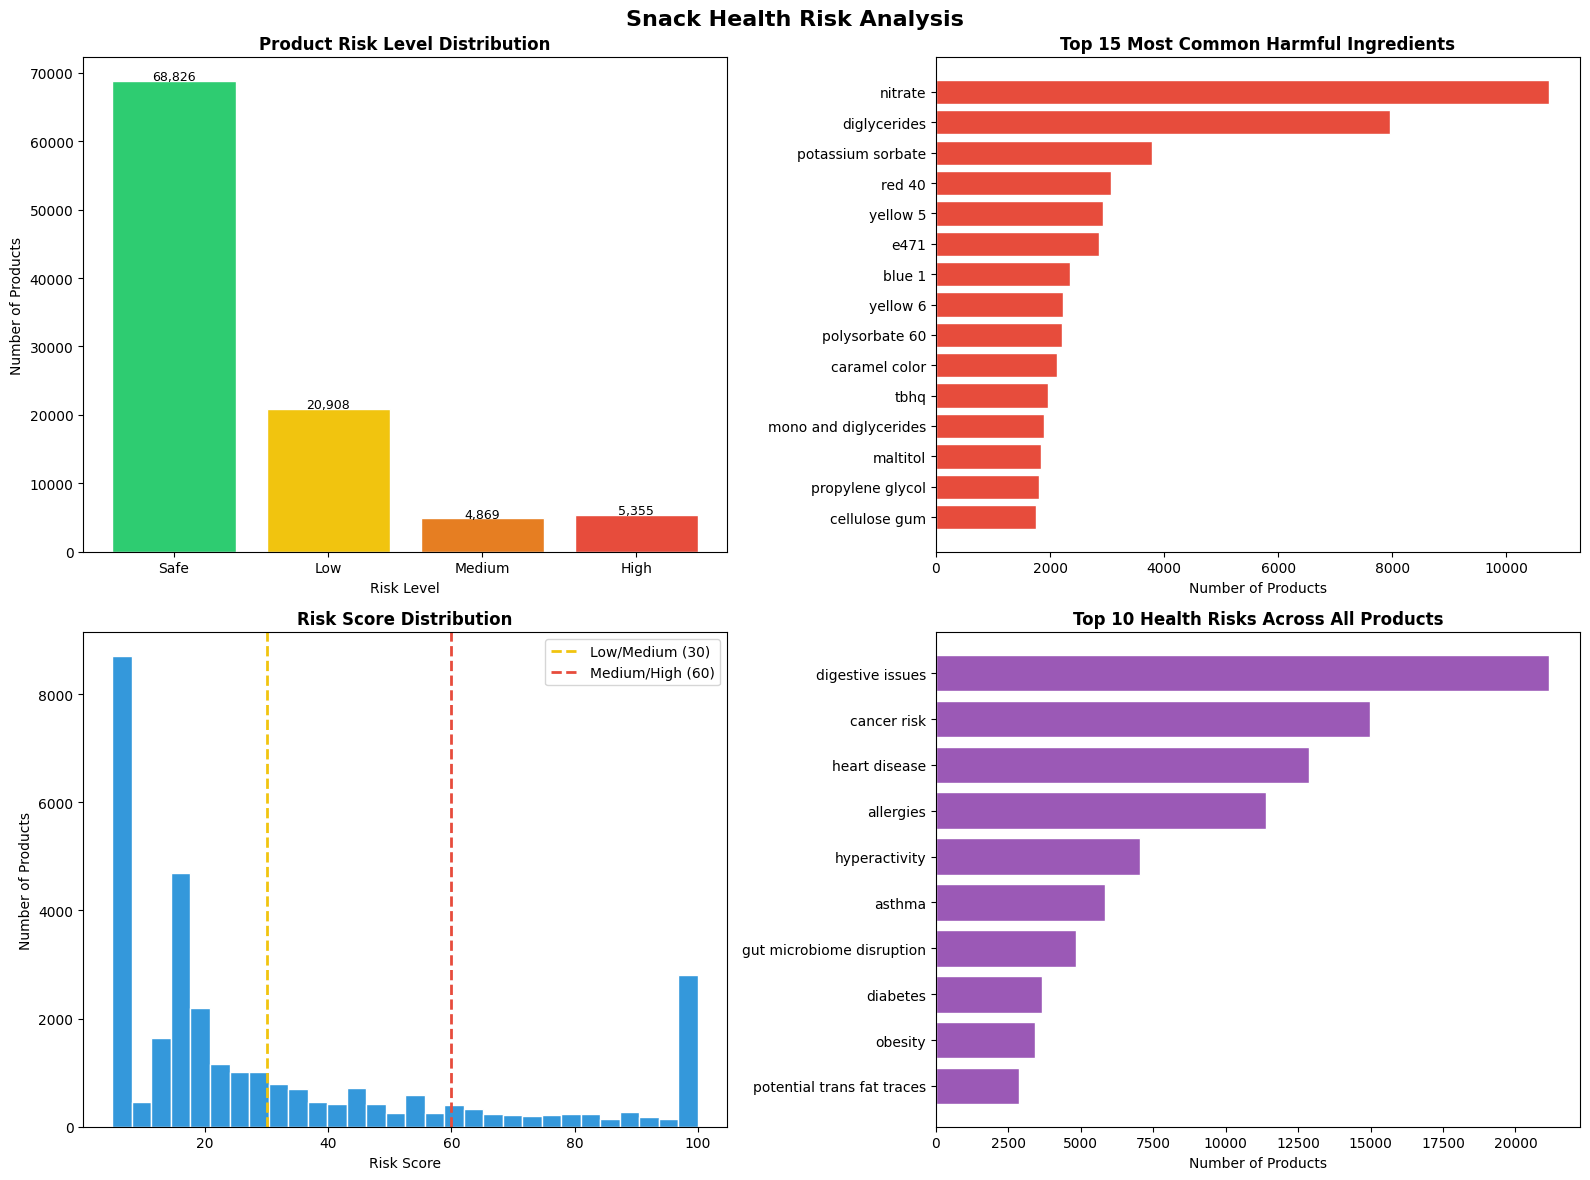

saved health_risk_analysis.png


In [ ]:
# STEP 6 — VISUALIZATIONS

# 4 charts — risk distribution, top harmful ingredients, score histogram, top diseases

#Risk Distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Snack Health Risk Analysis", fontsize=16, fontweight="bold")

risk_order = ["Safe", "Low", "Medium", "High"]
risk_counts = df["risk_level"].value_counts().reindex(risk_order, fill_value=0)
colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]
bars = axes[0, 0].bar(risk_counts.index, risk_counts.values, color=colors, edgecolor="white")
axes[0, 0].set_title("Product Risk Level Distribution", fontweight="bold")
axes[0, 0].set_xlabel("Risk Level")
axes[0, 0].set_ylabel("Number of Products")
for bar, val in zip(bars, risk_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                    f"{val:,}", ha="center", fontsize=9)

# Top Harmful Ingredients
all_keywords = []
for kws in df["harmful_ingredients_found"]:
    all_keywords.extend(kws)
kw_counts = Counter(all_keywords).most_common(15)
kw_labels = [k[0] for k in kw_counts][::-1]
kw_values = [k[1] for k in kw_counts][::-1]
axes[0, 1].barh(kw_labels, kw_values, color="#e74c3c", edgecolor="white")
axes[0, 1].set_title("Top 15 Most Common Harmful Ingredients", fontweight="bold")
axes[0, 1].set_xlabel("Number of Products")

# Score Histogram
nonzero = df[df["risk_score"] > 0]["risk_score"]
axes[1, 0].hist(nonzero, bins=30, color="#3498db", edgecolor="white")
axes[1, 0].axvline(30, color="#f1c40f", linestyle="--", linewidth=2, label="Low/Medium (30)")
axes[1, 0].axvline(60, color="#e74c3c", linestyle="--", linewidth=2, label="Medium/High (60)")
axes[1, 0].set_title("Risk Score Distribution", fontweight="bold")
axes[1, 0].set_xlabel("Risk Score")
axes[1, 0].set_ylabel("Number of Products")
axes[1, 0].legend()

# Top Diseases
top_diseases = disease_counts.most_common(10)
d_labels = [d[0] for d in top_diseases][::-1]
d_values = [d[1] for d in top_diseases][::-1]
axes[1, 1].barh(d_labels, d_values, color="#9b59b6", edgecolor="white")
axes[1, 1].set_title("Top 10 Health Risks Across All Products", fontweight="bold")
axes[1, 1].set_xlabel("Number of Products")

plt.tight_layout()
plt.savefig("health_risk_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved health_risk_analysis.png")

In [ ]:
# STEP 7 — PREPARE ML FEATURES
# building features for ML
# ingredient_count tells us how complex the product is
# additive_density normalizes harmful count by total ingredients
# a product with 3 harmful out of 6 is more concerning than 3 out of 30
def get_ingredient_count(val):
    try:
        lst = ast.literal_eval(str(val))
        return len(lst)
    except:
        return len(str(val).split(","))

df["ingredient_count"] = df["ingredients_list"].apply(get_ingredient_count)
df["additive_density"] = df["total_harmful_count"] / (df["ingredient_count"] + 1)

# dropping rows with unrealistically high ingredient counts — likely parsing errors
df = df[df["ingredient_count"] < 100]

feature_cols = (
    ["total_harmful_count", "ingredient_count", "additive_density"] +
    [f"count_{cat}" for cat in CATEGORIES]
)

X = df[feature_cols]
y = df["risk_level"]

# encode the target labels since sklearn needs numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"features ready: {feature_cols}")
print(f"X shape: {X.shape}")

features ready: ['total_harmful_count', 'ingredient_count', 'additive_density', 'count_artificial_color', 'count_preservative', 'count_sweetener', 'count_flavor_enhancer', 'count_additive', 'count_trans_fat', 'count_emulsifier']
X shape: (99794, 10)


In [ ]:
# STEP 8 — TRAIN TEST SPLIT & CROSS VALIDATION

# 80/20 split, stratified to keep class distribution consistent
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"train: {len(X_train):,}  |  test: {len(X_test):,}")

# quick cross-validation check before training proper models
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
cv_scores = cross_val_score(lr, X_train, y_train, cv=5)
print(f"5-fold CV: {cv_scores.round(3)}  mean: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

train: 79,835  |  test: 19,959
5-fold CV: [0.984 0.983 0.983 0.982 0.982]  mean: 0.983 (+/- 0.001)


In [ ]:
# STEP 09 — TRAIN MULTIPLE MODELS

# trying 4 different models to see which works best
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "LDA":                 LinearDiscriminantAnalysis(),
    "KNN":                 KNeighborsClassifier(n_neighbors=5),
    "Random Forest":       RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1)
}

print("\nmodel accuracies:")
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    results[name] = round(score, 4)
    print(f"  {name:<25} {score:.4f}")


model accuracies:
  Logistic Regression       0.9815
  LDA                       0.9079
  KNN                       0.9805
  Random Forest             0.9810


In [ ]:
# STEP 10 — HYPERPARAMETER TUNING
# tuning random forest — testing different tree counts, depths, and split sizes
print("\ntuning random forest...")
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}
rf = RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1)
# using f1_weighted here instead of accuracy since classes are imbalanced
grid = GridSearchCV(rf, param_grid, cv=3, scoring="f1_weighted", n_jobs=-1)
grid.fit(X_train, y_train)

print(f"best params: {grid.best_params_}")
print(f"best CV score: {grid.best_score_:.4f}")


tuning random forest...
best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
best CV score: 0.9950



classification report:
              precision    recall  f1-score   support

        High       0.86      0.94      0.90       102
         Low       0.99      0.96      0.98      2061
      Medium       0.83      0.93      0.88       460
        Safe       1.00      1.00      1.00     17336

    accuracy                           0.99     19959
   macro avg       0.92      0.96      0.94     19959
weighted avg       0.99      0.99      0.99     19959



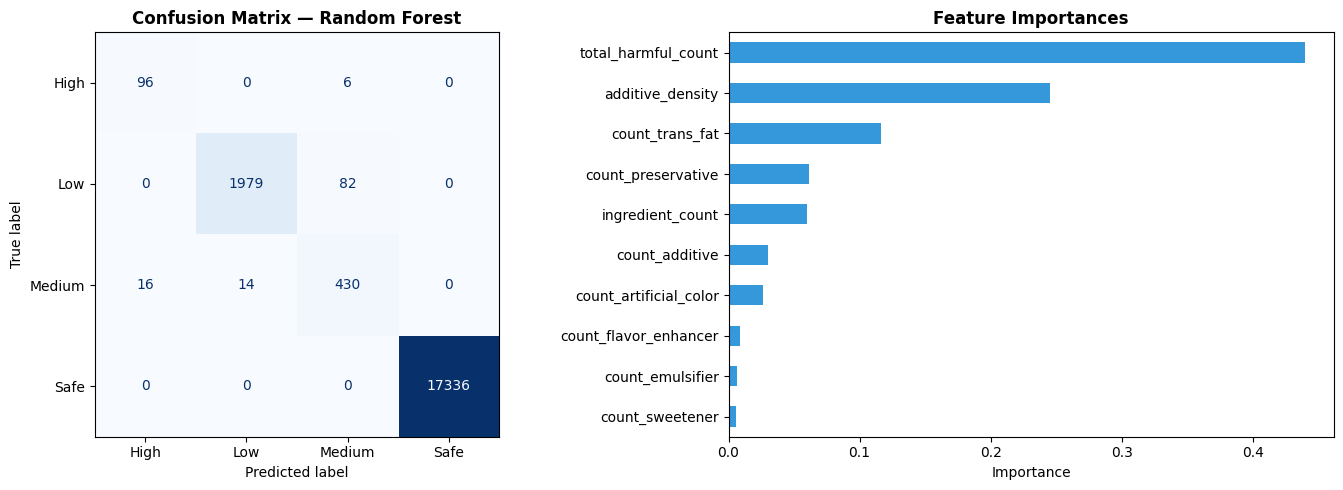

saved model_evaluation.png
saved snacks_final.csv — 99,794 rows

top 10 highest risk products:
                                      product_name  risk_score risk_level                                                                                                       harmful_ingredients_found
160                                      ClÃ¡sicos         100       High                                                                        e102, e129, e133, allura red, e320, bha, e321, bht, tbhq
1340                 Prawn Crackers - Spicy Flavor         100       High    e102, e129, e150, e320, bha, e321, bht, tbhq, e951, aspartame, e621, monosodium glutamate, e627, e631, e551, silicon dioxide
2051                                      Hand pie         100       High            sodium benzoate, bha, carrageenan, titanium dioxide, silicon dioxide, partially hydrogenated, hydrogenated vegetable
6874         GRILLED BARBEQUE FLAVOURED CORN CHIPS         100       High                        

In [ ]:
# STEP 11 — FINAL EVALUATION
# final evaluation on held-out test set
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\nclassification report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# confusion matrix and feature importance side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix — Random Forest", fontweight="bold")

importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind="barh", ax=axes[1], color="#3498db")
axes[1].set_title("Feature Importances", fontweight="bold")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved model_evaluation.png")

# adding model predictions to the dataframe and saving everything
df["predicted_risk_level"] = le.inverse_transform(best_model.predict(X))

df["harmful_ingredients_found"] = df["harmful_ingredients_found"].apply(
    lambda x: ", ".join(x) if x else "none"
)
df["health_risks"] = df["health_risks"].apply(
    lambda x: ", ".join(x) if x else "none"
)

output_cols = [
    "product_name", "categories_en", "ingredients_cleaned",
    "harmful_ingredients_found", "total_harmful_count",
    "count_artificial_color", "count_preservative", "count_sweetener",
    "count_flavor_enhancer", "count_additive", "count_trans_fat", "count_emulsifier",
    "ingredient_count", "additive_density",
    "risk_score", "risk_level", "predicted_risk_level", "health_risks"
]

df[output_cols].to_csv("snacks_final.csv", index=False)
print(f"saved snacks_final.csv — {len(df):,} rows")

print("\ntop 10 highest risk products:")
top10 = df.nlargest(10, "risk_score")[["product_name", "risk_score", "risk_level", "harmful_ingredients_found"]]
print(top10.to_string())

print("\ndone!")